 # REGRESIÓN LINEAL MULTIPLE - MEDICAL COST PERSONAL

## 1 - IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2 - CARGAMOS DATASET

In [4]:
import pandas as pd
df = pd.read_csv("insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [10]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [11]:
df_model = pd.get_dummies(df, drop_first=True)

df_model.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## 3 - CORRELACIONES

In [12]:
plt.rcParams['figure.figsize'] = (12, 8)

<Axes: >

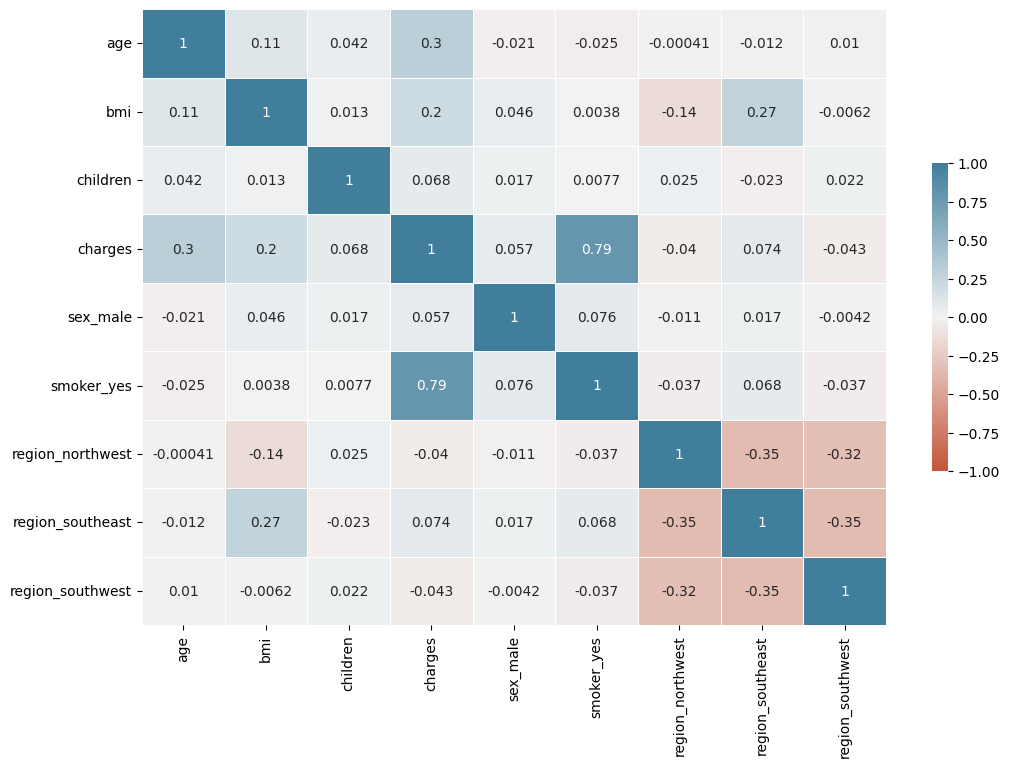

In [15]:
sns.heatmap(
    data=df_model.corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## 4 - CREAMOS UN MAPA DE CALOR DE LA VARIABLE DEPENDIENTE CHARGES CONTRA TODAS LAS DEMAS

In [16]:
corr_matrix = df_model.corr()
corr_charges = corr_matrix[['charges']].sort_values(by='charges',ascending=False)
corr_charges

,charges
charges,1.000000
smoker_yes,0.787251
age,0.299008
bmi,0.198341
region_southeast,0.073982
children,0.067998
sex_male,0.057292
region_northwest,-0.039905
region_southwest,-0.043210


<Axes: >

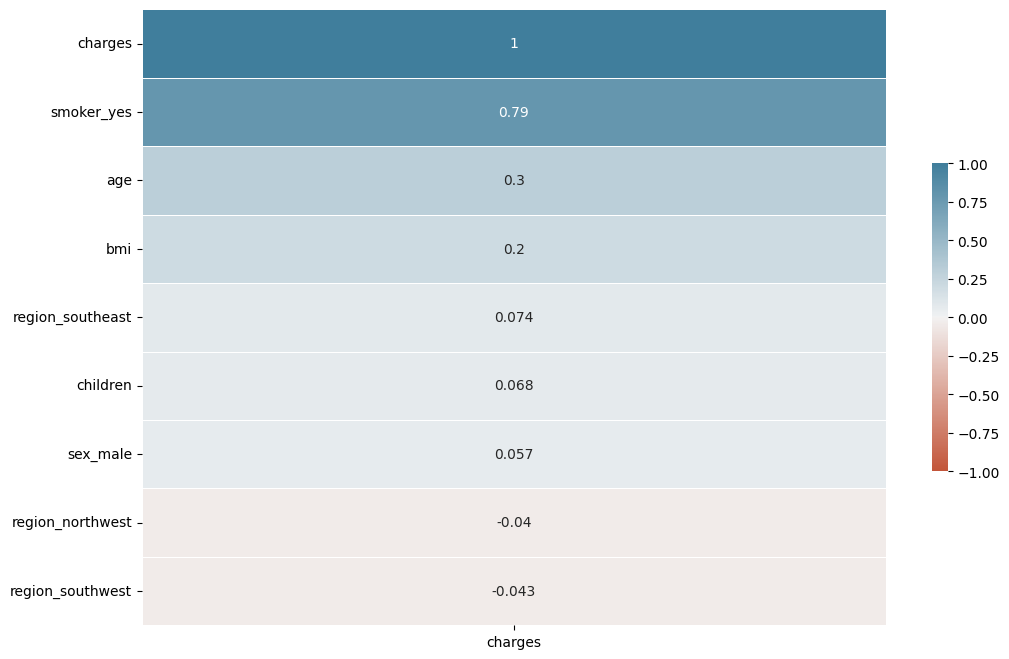

In [20]:
sns.heatmap(
    data=corr_charges,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5},
    annot=True
)

In [21]:
cols = corr_charges.index.tolist()
cols.remove('charges')
cols

['smoker_yes',
 'age',
 'bmi',
 'region_southeast',
 'children',
 'sex_male',
 'region_northwest',
 'region_southwest']

## 5 - CREAMOS UN MODELO DE REGRESIÓN LINEAL SIMPLE PARA X = AGE Y = CHARGES

## 1 - DEFINIR VARIABLE X y Y

* X = AGE(PROMEDIO DE EDAD)
* Y = CHARGES(VALOR PROMEDIO DE LA POLIZA)

In [26]:
X = df_model[cols].values
y = df['charges'].values.reshape(-1,1)

In [25]:
X

array([[True, 19, 27.9, ..., False, False, True],
       [False, 18, 33.77, ..., True, False, False],
       [False, 28, 33.0, ..., True, False, False],
       ...,
       [False, 18, 36.85, ..., False, False, False],
       [False, 21, 25.8, ..., False, False, True],
       [True, 61, 29.07, ..., False, True, False]], dtype=object)

## 1.1 DIVIDIR DATASET EN TRAIN Y TEST

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
print(f' X_train(valores de X para entrenamiento) : {X_train.shape[0]}')
print(f' y_train(valores de y para entrenamiento) : {y_train.shape[0]}')
print(f' X_test(valores de X para prueba) : {X_test.shape[0]}')
print(f' y_test(valores de y para prueba) : {y_test.shape[0]}')

 X_train(valores de X para entrenamiento) : 936
 y_train(valores de y para entrenamiento) : 936
 X_test(valores de X para prueba) : 402
 y_test(valores de y para prueba) : 402


# CALCULAMOS PROMEDIO Y STD

In [29]:
print(f'Promedio de X_train : {X_train.mean()}')
print(f'Desviación standard de X_train : {X_train.std()}')

Promedio de X_train : 9.03899105235043
Desviación standard de X_train : 16.027212572648583


## 1.2 ESTANDARIZAMOS VALORES CON STANDARSCALER

In [30]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.transform(y_test)

In [31]:
print(f'Promedio de X_train : {X_train.mean()}')
print(f'Desviación standard de X_train : {X_train.std()}')

Promedio de X_train : 1.708035422500241e-16
Desviación standard de X_train : 1.0000000000000013


## 2 - IMPORTAR LIBREARIAS DE SKLEARN

In [32]:
from sklearn.linear_model import LinearRegression

## 3 - CREAMOS EL MODELO Y LO ENTRENAMOS CON LA DATA

In [37]:
slr = LinearRegression()
slr.fit(X_train,y_train)
y_pred = slr.predict(X_test)

## 4 - GRAFICAMOS LO REAL VS LOS PREDICHO

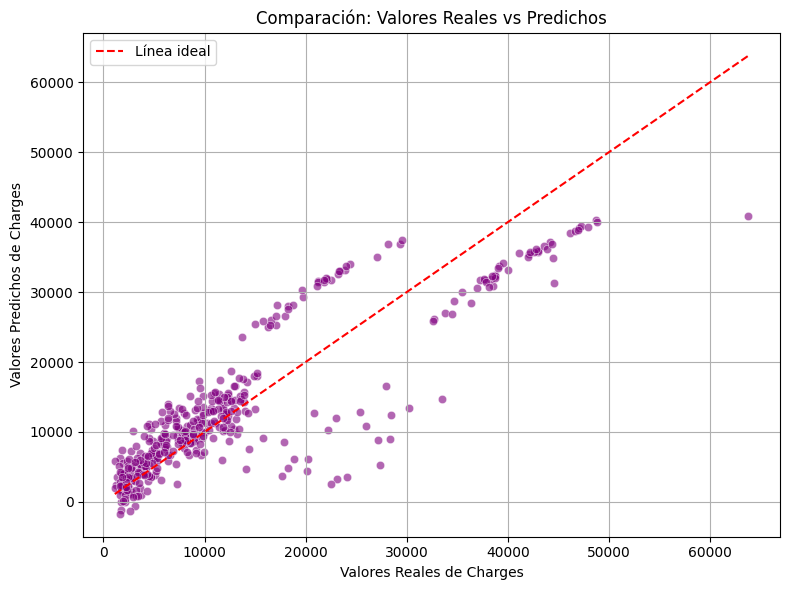

In [39]:
# Invertimos la escala para llevar y_test y y_pred a sus valores originales
y_test_real = sc_y.inverse_transform(y_test)
y_pred_real = sc_y.inverse_transform(y_pred)

# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_real.flatten(), y=y_pred_real.flatten(), color='purple', alpha=0.6)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         color='red', linestyle='--', label='Línea ideal')

plt.xlabel('Valores Reales de Charges')
plt.ylabel('Valores Predichos de Charges')
plt.title('Comparación: Valores Reales vs Predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6 - METRICAS DEL MODELO

In [40]:
import sklearn.metrics as metrics

# ERROR CUADRATICO MEDIO
mse = metrics.mean_squared_error(y_test,y_pred)
# R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 0.2306
El coeficiente de determinación(R2) es de 0.7696


# 7 - PROBAMOS UNA PREDICCIÓN CON NUEVOS DATOS

In [42]:
X_new = np.array([[0, 30.0, 25.0, 0, 0, 1, 1, 0]]) # Example values for: smoker_yes (False), age (30), bmi (25.0), region_southeast (False), children (0), sex_male (True), region_northwest (True), region_southwest (False)

# Asegurarse de que X_new tiene el mismo número de características que X_train
# Las características en 'cols' son: ['smoker_yes', 'age', 'bmi', 'region_southeast', 'children', 'sex_male', 'region_northwest', 'region_southwest']
# Revisa que las columnas de X_new coincidan con 'cols' en orden y número.
# Para este ejemplo, estoy asumiendo que el orden de las columnas en X_new es el mismo que en 'cols'.
# El ejemplo proporcionado en X_new tiene 8 valores, que coincide con la longitud de 'cols'.

# Escalar los nuevos datos
X_new_scaled = sc_x.transform(X_new)

# Realizar la predicción
y_new_pred_scaled = slr.predict(X_new_scaled)

# Invertir la escala para obtener el valor real
y_new_pred_real = sc_y.inverse_transform(y_new_pred_scaled)

print(f"El valor de Charges predicho para los nuevos datos es: {y_new_pred_real[0][0]:.2f}")

El valor de Charges predicho para los nuevos datos es: 3805.49
